In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.unicode_minus'] = False

columns = ['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Class']
df = pd.read_csv('iris.data', header=None, names=columns)
df = df.dropna(how='all').reset_index(drop=True)

print('Data shape:', df.shape)
print('\nDtypes:\n', df.dtypes)
print('\nClass distribution:\n', df['Class'].value_counts())

df.head()

Data shape: (150, 5)

Dtypes:
 SepalLength    float64
SepalWidth     float64
PetalLength    float64
PetalWidth     float64
Class           object
dtype: object

Class distribution:
 Class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


,SepalLength,SepalWidth,PetalLength,PetalWidth,Class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
# 选择 sepal length 与 petal length 两维做聚类
feature_cols = ['SepalLength', 'PetalLength']
X = df[feature_cols].to_numpy(dtype=float)

# 将字符串类别映射为 0/1/2，便于后续做聚类效果评估
label_map = {
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
}
y_true = df['Class'].map(label_map).to_numpy(dtype=int)

print('X shape:', X.shape)
print('y_true shape:', y_true.shape)
print('Feature columns:', feature_cols)
print('First 5 samples of X:\n', X[:5])
print('First 10 labels of y_true:', y_true[:10])

X shape: (150, 2)
y_true shape: (150,)
Feature columns: ['SepalLength', 'PetalLength']
First 5 samples of X:
 [[5.1 1.4]
 [4.9 1.4]
 [4.7 1.3]
 [4.6 1.5]
 [5.  1.4]]
First 10 labels of y_true: [0 0 0 0 0 0 0 0 0 0]


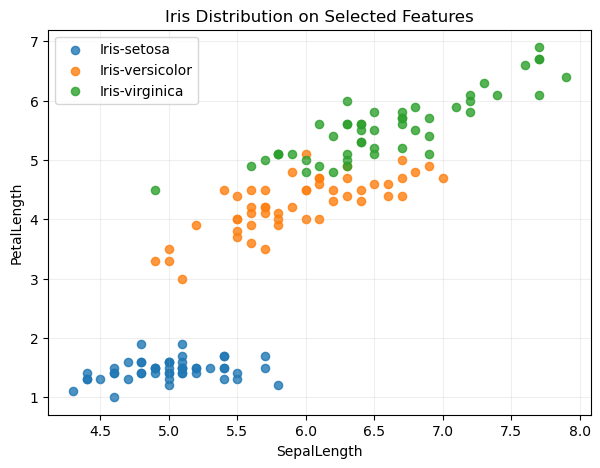

In [49]:
# 先看真实类别在二维特征空间中的分布，便于后续和聚类结果做对比
class_names = {0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'}
colors = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c'}

plt.figure()
for cls in [0, 1, 2]:
    mask = (y_true == cls)
    plt.scatter(
        X[mask, 0], X[mask, 1],
        s=35, alpha=0.8, c=colors[cls], label=class_names[cls]
    )

plt.xlabel('SepalLength')
plt.ylabel('PetalLength')
plt.title('Iris Distribution on Selected Features')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [ ]:
# 说明：后续分配样本到最近中心时，只比较距离大小，因此直接用平方距离即可。
def squared_euclidean_distance(a, b):
    """计算两个向量之间的平方欧氏距离。"""
    diff = a - b
    return np.sum(diff * diff)

# 简单自检：手算应为 (1-3)^2 + (2-5)^2 = 13
print('distance test:', squared_euclidean_distance(np.array([1, 2]), np.array([3, 5])))

distance test: 13


In [ ]:
# 随机初始化K个聚类中心（无放回抽样）
# 从样本中随机选K个点作为初始中心。

def initialize_centroids(X, k=3, random_state=42):
    """从数据X中随机无放回选择k个样本作为初始中心。"""
    rng = np.random.default_rng(random_state)
    indices = rng.choice(X.shape[0], size=k, replace=False)
    centroids = X[indices].copy()
    return centroids, indices

centroids_init, init_indices = initialize_centroids(X, k=3, random_state=42)
print('initial indices:', init_indices)
print('initial centroids:\n', centroids_init)

initial indices: [ 98  13 115]
initial centroids:
 [[5.1 3. ]
 [4.3 1.1]
 [6.4 5.3]]


In [ ]:
# 分配步骤（将每个样本分到最近的聚类中心）

def assign_clusters(X, centroids):
    """返回每个样本所属的簇标签（0~k-1）。"""
    n_samples = X.shape[0]
    k = centroids.shape[0]
    labels = np.zeros(n_samples, dtype=int)

    for i in range(n_samples):
        dists = np.zeros(k)
        for j in range(k):
            dists[j] = squared_euclidean_distance(X[i], centroids[j])
        labels[i] = np.argmin(dists)

    return labels

labels_init = assign_clusters(X, centroids_init)
print('labels shape:', labels_init.shape)
print('first 20 labels:', labels_init[:20])

labels shape: (150,)
first 20 labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1]


In [ ]:
# 更新步骤（按簇内样本均值更新中心）
# 若出现空簇，则随机挑一个样本重新作为该簇中心。

def update_centroids(X, labels, k=3, random_state=42):
    """根据labels更新k个聚类中心。"""
    rng = np.random.default_rng(random_state)
    n_features = X.shape[1]
    new_centroids = np.zeros((k, n_features), dtype=float)

    for cluster_id in range(k):
        cluster_points = X[labels == cluster_id]
        if cluster_points.shape[0] == 0:
            random_idx = rng.integers(0, X.shape[0])
            new_centroids[cluster_id] = X[random_idx]
        else:
            new_centroids[cluster_id] = np.mean(cluster_points, axis=0)

    return new_centroids

centroids_next = update_centroids(X, labels_init, k=3, random_state=42)
print('updated centroids:\n', centroids_next)

updated centroids:
 [[5.45909091 3.63636364]
 [4.98958333 1.45      ]
 [6.46125    5.1775    ]]


In [ ]:
# 计算目标函数SSE（簇内平方和）

def compute_sse(X, labels, centroids):
    """SSE = sum(||x_i - mu_{label_i}||^2)。"""
    sse = 0.0
    for i in range(X.shape[0]):
        cluster_id = labels[i]
        sse += squared_euclidean_distance(X[i], centroids[cluster_id])
    return sse

sse_init = compute_sse(X, labels_init, centroids_init)
sse_next = compute_sse(X, labels_init, centroids_next)
print('SSE with initial centroids:', sse_init)
print('SSE after one centroid update (same labels):', sse_next)

SSE with initial centroids: 121.99000000000002
SSE after one centroid update (same labels): 80.03825757575758


In [55]:
# K-Means主流程：迭代执行“分配->更新”，直到收敛或达到最大迭代次数

def kmeans_fit(X, k=3, max_iter=1000, tol=1e-6, random_state=42):
    centroids, _ = initialize_centroids(X, k=k, random_state=random_state)
    sse_history = []

    for it in range(max_iter):
        labels = assign_clusters(X, centroids)
        sse = compute_sse(X, labels, centroids)
        sse_history.append(sse)

        new_centroids = update_centroids(X, labels, k=k, random_state=random_state + it + 1)
        centroid_shift = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids

        if centroid_shift < tol:
            break

    final_labels = assign_clusters(X, centroids)
    final_sse = compute_sse(X, final_labels, centroids)
    sse_history.append(final_sse)

    return centroids, final_labels, sse_history

kmeans_centroids, kmeans_labels, kmeans_sse_history = kmeans_fit(
    X, k=3, max_iter=1000, tol=1e-6, random_state=42
)

print('iterations:', len(kmeans_sse_history) - 1)
print('final centroids:\n', kmeans_centroids)
print('initial SSE:', kmeans_sse_history[0])
print('final SSE:', kmeans_sse_history[-1])

iterations: 10
final centroids:
 [[5.87413793 4.39310345]
 [5.00784314 1.49411765]
 [6.83902439 5.67804878]]
initial SSE: 121.99000000000002
final SSE: 53.801351193126536


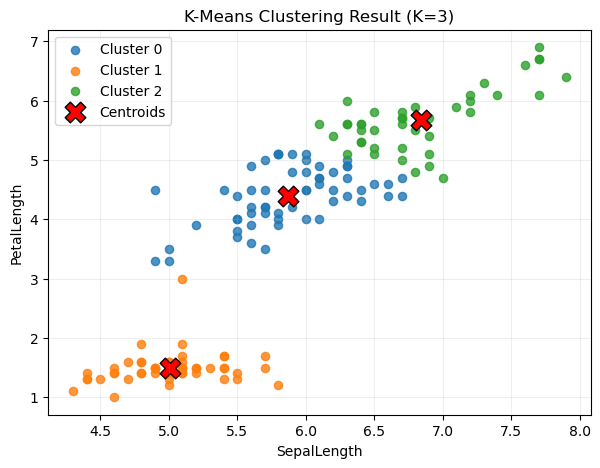

In [ ]:
# 可视化K-Means聚类结果

cluster_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure()
for cid in range(3):
    mask = (kmeans_labels == cid)
    plt.scatter(
        X[mask, 0], X[mask, 1],
        s=35, alpha=0.8, c=cluster_colors[cid], label=f'Cluster {cid}'
    )

plt.scatter(
    kmeans_centroids[:, 0], kmeans_centroids[:, 1],
    s=220, c='red', marker='X', edgecolors='black', linewidths=1.0,
    label='Centroids'
)

plt.xlabel('SepalLength')
plt.ylabel('PetalLength')
plt.title('K-Means Clustering Result (K=3)')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

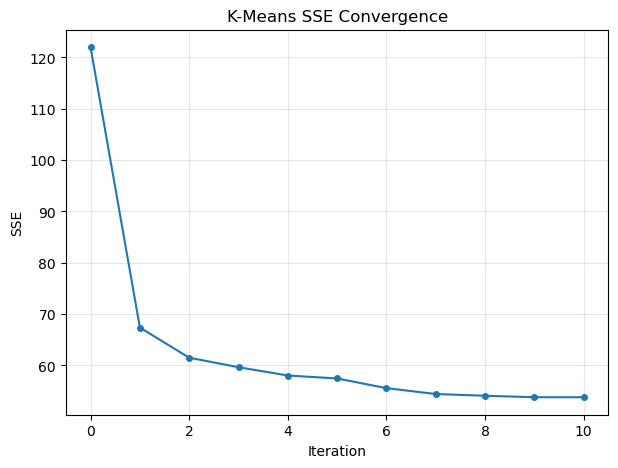

In [57]:
# 绘制K-Means的SSE收敛曲线

plt.figure()
plt.plot(range(len(kmeans_sse_history)), kmeans_sse_history, marker='o', markersize=4)
plt.xlabel('Iteration')
plt.ylabel('SSE')
plt.title('K-Means SSE Convergence')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# 多元高斯概率密度函数
# phi(x|mu,Sigma) = 1 / ((2pi)^(d/2) * |Sigma|^(1/2)) * exp(-0.5 * (x-mu)^T * Sigma^{-1} * (x-mu))
# 这里加入了微小对角扰动eps，避免Sigma奇异导致无法求逆。

def multivariate_gaussian_pdf(x, mu, sigma, eps=1e-6):
    """计算单个样本x在N(mu, sigma)下的概率密度值。"""
    d = x.shape[0]
    sigma_stable = sigma + eps * np.eye(d)

    det_sigma = np.linalg.det(sigma_stable)
    inv_sigma = np.linalg.inv(sigma_stable)
    diff = x - mu

    norm_const = 1.0 / (np.power(2 * np.pi, d / 2) * np.sqrt(det_sigma))
    exponent = -0.5 * (diff.T @ inv_sigma @ diff)
    return norm_const * np.exp(exponent)

# 简单自检：二维标准高斯在原点附近应有较大密度
x_test = np.array([0.0, 0.0])
mu_test = np.array([0.0, 0.0])
sigma_test = np.array([[1.0, 0.0], [0.0, 1.0]])
print('pdf test:', multivariate_gaussian_pdf(x_test, mu_test, sigma_test))

pdf test: 0.15915478393711144


In [ ]:
# 初始化参数 alpha, mu, Sigma

def initialize_gmm_params(X, k=3, random_state=42):
    """初始化GMM参数：混合系数alpha、均值mu、协方差Sigma。"""
    rng = np.random.default_rng(random_state)
    n_samples, n_features = X.shape

    # alpha_k 初始设为均匀分布
    alpha = np.ones(k, dtype=float) / k

    # mu_k 从样本中随机无放回选择k个点
    indices = rng.choice(n_samples, size=k, replace=False)
    mu = X[indices].copy()

    # Sigma_k 初始设为整体样本协方差（每个分量同一初值）
    base_cov = np.cov(X.T)
    sigma = np.array([base_cov.copy() for _ in range(k)])

    return alpha, mu, sigma

gmm_alpha, gmm_mu, gmm_sigma = initialize_gmm_params(X, k=3, random_state=42)
print('alpha:', gmm_alpha)
print('mu shape:', gmm_mu.shape)
print('sigma shape:', gmm_sigma.shape)
print('first mu:\n', gmm_mu[0])
print('first Sigma:\n', gmm_sigma[0])

alpha: [0.33333333 0.33333333 0.33333333]
mu shape: (3, 2)
sigma shape: (3, 2, 2)
first mu:
 [5.1 3. ]
first Sigma:
 [[0.68569351 1.27368233]
 [1.27368233 3.11317942]]


In [ ]:
# E-step，计算响应度 gamma_{jk}
# gamma_{jk} = alpha_k * phi(x_j|mu_k,Sigma_k) / sum_l alpha_l * phi(x_j|mu_l,Sigma_l)

def e_step(X, alpha, mu, sigma, eps=1e-12):
    """返回响应度矩阵gamma，形状为 (n_samples, k)。"""
    n_samples = X.shape[0]
    k = alpha.shape[0]
    gamma = np.zeros((n_samples, k), dtype=float)

    for j in range(n_samples):
        weights = np.zeros(k, dtype=float)
        for comp in range(k):
            pdf_val = multivariate_gaussian_pdf(X[j], mu[comp], sigma[comp])
            weights[comp] = alpha[comp] * pdf_val

        total = np.sum(weights)
        if total < eps:
            # 极端情况下避免除零：退化为均匀响应度
            gamma[j] = np.ones(k) / k
        else:
            gamma[j] = weights / total

    return gamma

gamma_init = e_step(X, gmm_alpha, gmm_mu, gmm_sigma)
print('gamma shape:', gamma_init.shape)
print('first sample gamma:', gamma_init[0])
print('row-sum check (first 5):', np.sum(gamma_init[:5], axis=1))

gamma shape: (150, 3)
first sample gamma: [0.36680935 0.49763188 0.13555877]
row-sum check (first 5): [1. 1. 1. 1. 1.]


In [ ]:
# M-step，更新参数 alpha, mu, Sigma
# N_k = sum_j gamma_{jk}
# mu_k = (sum_j gamma_{jk} * x_j) / N_k
# Sigma_k = (sum_j gamma_{jk} * (x_j-mu_k)(x_j-mu_k)^T) / N_k
# alpha_k = N_k / N

def m_step(X, gamma, eps=1e-6):
    """根据响应度gamma更新GMM参数。"""
    n_samples, n_features = X.shape
    k = gamma.shape[1]

    Nk = np.sum(gamma, axis=0) + 1e-12
    alpha_new = Nk / n_samples

    mu_new = np.zeros((k, n_features), dtype=float)
    sigma_new = np.zeros((k, n_features, n_features), dtype=float)

    for comp in range(k):
        # 更新 mu_k
        weighted_sum = np.sum(gamma[:, comp][:, None] * X, axis=0)
        mu_new[comp] = weighted_sum / Nk[comp]

        # 更新 Sigma_k
        diff = X - mu_new[comp]
        cov = np.zeros((n_features, n_features), dtype=float)
        for j in range(n_samples):
            cov += gamma[j, comp] * np.outer(diff[j], diff[j])
        sigma_new[comp] = cov / Nk[comp]

        # 数值稳定：给协方差加微小对角项，避免奇异
        sigma_new[comp] += eps * np.eye(n_features)

    return alpha_new, mu_new, sigma_new

alpha_new, mu_new, sigma_new = m_step(X, gamma_init)
print('alpha_new:', alpha_new)
print('sum(alpha_new):', np.sum(alpha_new))
print('mu_new shape:', mu_new.shape)
print('sigma_new shape:', sigma_new.shape)

alpha_new: [0.31555857 0.20989889 0.47454255]
sum(alpha_new): 1.00000000000002
mu_new shape: (3, 2)
sigma_new shape: (3, 2, 2)


In [ ]:
# 计算对数似然 log-likelihood
# L(theta) = sum_j log( sum_k alpha_k * phi(x_j|mu_k,Sigma_k) )

def compute_log_likelihood(X, alpha, mu, sigma, eps=1e-12):
    """计算当前参数下全部样本的对数似然值。"""
    n_samples = X.shape[0]
    k = alpha.shape[0]
    log_likelihood = 0.0

    for j in range(n_samples):
        prob_sum = 0.0
        for comp in range(k):
            prob_sum += alpha[comp] * multivariate_gaussian_pdf(X[j], mu[comp], sigma[comp])
        log_likelihood += np.log(prob_sum + eps)

    return log_likelihood

ll_init = compute_log_likelihood(X, gmm_alpha, gmm_mu, gmm_sigma)
ll_after_one_em = compute_log_likelihood(X, alpha_new, mu_new, sigma_new)
print('log-likelihood (initial):', ll_init)
print('log-likelihood (after one EM update):', ll_after_one_em)

log-likelihood (initial): -434.27660674164787
log-likelihood (after one EM update): -359.2830431129461


In [ ]:
# EM迭代（E-step + M-step），直到收敛或达到最大迭代次数

def gmm_fit(X, k=3, max_iter=1000, tol=1e-6, random_state=42):
    alpha, mu, sigma = initialize_gmm_params(X, k=k, random_state=random_state)
    ll_history = []

    for it in range(max_iter):
        # E-step：计算响应度
        gamma = e_step(X, alpha, mu, sigma)

        # M-step：更新参数
        alpha, mu, sigma = m_step(X, gamma)

        # 记录当前对数似然
        ll = compute_log_likelihood(X, alpha, mu, sigma)
        ll_history.append(ll)

        # 收敛判定：相邻两轮log-likelihood提升很小
        if len(ll_history) > 1 and abs(ll_history[-1] - ll_history[-2]) < tol:
            break

    # 最终软分配 -> 硬标签（取最大响应度）
    final_gamma = e_step(X, alpha, mu, sigma)
    final_labels = np.argmax(final_gamma, axis=1)

    return alpha, mu, sigma, final_gamma, final_labels, ll_history

gmm_alpha_final, gmm_mu_final, gmm_sigma_final, gmm_gamma_final, gmm_labels, gmm_ll_history = gmm_fit(
    X, k=3, max_iter=1000, tol=1e-6, random_state=5
)

print('iterations:', len(gmm_ll_history))
print('final alpha:', gmm_alpha_final)
print('final mu:\n', gmm_mu_final)
print('initial log-likelihood:', gmm_ll_history[0])
print('final log-likelihood:', gmm_ll_history[-1])

iterations: 144
final alpha: [0.29987472 0.36679212 0.33333316]
final mu:
 [[6.54892797 5.57406767]
 [6.02741839 4.35981294]
 [5.0060001  1.46399978]]
initial log-likelihood: -359.4106125505349
final log-likelihood: -250.31658110088043


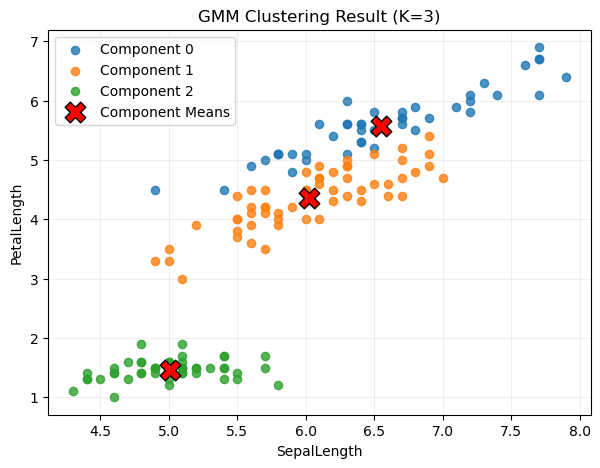

In [ ]:
# 可视化GMM聚类结果

cluster_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure()
for cid in range(3):
    mask = (gmm_labels == cid)
    plt.scatter(
        X[mask, 0], X[mask, 1],
        s=35, alpha=0.8, c=cluster_colors[cid], label=f'Component {cid}'
    )

plt.scatter(
    gmm_mu_final[:, 0], gmm_mu_final[:, 1],
    s=220, c='red', marker='X', edgecolors='black', linewidths=1.0,
    label='Component Means'
)

plt.xlabel('SepalLength')
plt.ylabel('PetalLength')
plt.title('GMM Clustering Result (K=3)')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

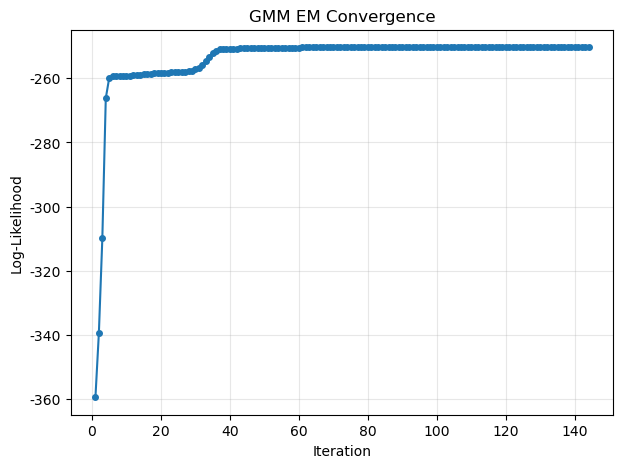

In [65]:
# 绘制GMM的log-likelihood收敛曲线

plt.figure()
plt.plot(range(1, len(gmm_ll_history) + 1), gmm_ll_history, marker='o', markersize=4)
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.title('GMM EM Convergence')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# 标签对齐准确率（输出6种映射情况）

from itertools import permutations

def clustering_accuracy_with_permutations(y_true, y_pred, n_classes=3, algo_name='算法'):
    """输出所有标签映射的准确率，并返回最大准确率及最佳映射。"""
    perms = list(permutations(range(n_classes)))
    results = []

    print(f'\n【{algo_name}】6种标签映射下的准确率：')
    for idx, perm in enumerate(perms, start=1):
        # perm的含义：预测标签0/1/2分别映射到真实标签perm[0]/perm[1]/perm[2]
        mapped = np.array([perm[label] for label in y_pred], dtype=int)
        acc = np.mean(mapped == y_true)
        results.append((perm, acc))
        print(f'情况{idx}: 映射 {perm} -> 准确率 = {acc:.4f}')

    best_perm, best_acc = max(results, key=lambda x: x[1])
    print(f'【{algo_name}】最大准确率 = {best_acc:.4f}，最佳映射 = {best_perm}')

    return best_acc, best_perm, results

kmeans_best_acc, kmeans_best_perm, kmeans_all_results = clustering_accuracy_with_permutations(
    y_true, kmeans_labels, n_classes=3, algo_name='K-Means'
)


【K-Means】6种标签映射下的准确率：
情况1: 映射 (0, 1, 2) -> 准确率 = 0.2533
情况2: 映射 (0, 2, 1) -> 准确率 = 0.0267
情况3: 映射 (1, 0, 2) -> 准确率 = 0.8800
情况4: 映射 (1, 2, 0) -> 准确率 = 0.3000
情况5: 映射 (2, 0, 1) -> 准确率 = 0.4467
情况6: 映射 (2, 1, 0) -> 准确率 = 0.0933
【K-Means】最大准确率 = 0.8800，最佳映射 = (1, 0, 2)


In [67]:
# 评估模块(2)：评估GMM，并和K-Means做最大准确率对比

gmm_best_acc, gmm_best_perm, gmm_all_results = clustering_accuracy_with_permutations(
    y_true, gmm_labels, n_classes=3, algo_name='GMM'
)

print('\n【两种算法最大准确率对比】')
print(f'K-Means 最大准确率: {kmeans_best_acc:.4f} (最佳映射={kmeans_best_perm})')
print(f'GMM     最大准确率: {gmm_best_acc:.4f} (最佳映射={gmm_best_perm})')

if kmeans_best_acc > gmm_best_acc:
    print('结论：在当前设置下，K-Means 准确率更高。')
elif gmm_best_acc > kmeans_best_acc:
    print('结论：在当前设置下，GMM 准确率更高。')
else:
    print('结论：在当前设置下，两者准确率相同。')


【GMM】6种标签映射下的准确率：
情况1: 映射 (0, 1, 2) -> 准确率 = 0.3133
情况2: 映射 (0, 2, 1) -> 准确率 = 0.0600
情况3: 映射 (1, 0, 2) -> 准确率 = 0.0200
情况4: 映射 (1, 2, 0) -> 准确率 = 0.4133
情况5: 映射 (2, 0, 1) -> 准确率 = 0.2733
情况6: 映射 (2, 1, 0) -> 准确率 = 0.9200
【GMM】最大准确率 = 0.9200，最佳映射 = (2, 1, 0)

【两种算法最大准确率对比】
K-Means 最大准确率: 0.8800 (最佳映射=(1, 0, 2))
GMM     最大准确率: 0.9200 (最佳映射=(2, 1, 0))
结论：在当前设置下，GMM 准确率更高。
